<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_week7(168).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q18:LE-NET 5
Adequate but Not Perfect: LeNet-5 was invented in the 1990s specifically to read simple handwritten digits (like postal codes). Fashion MNIST has much more complex textures and edges (e.g., distinguishing a pullover from a long-sleeve shirt). The model will achieve roughly 88% to 89% accuracy, which is good, but modern architectures easily break 92%+.

tanh vs. relu: This original architecture uses tanh activations. You will notice that training starts off a bit slower than it would if you used the modern relu activation function, because tanh gradients can vanish on the edges.

Overfitting Risk: By epoch 15-20, you will likely notice the loss continuing to drop while the val_loss (validation loss) levels out or slightly increases. Because classic LeNet-5 does not include Dropout layers, it tends to memorize the training images slightly toward the end of the run.

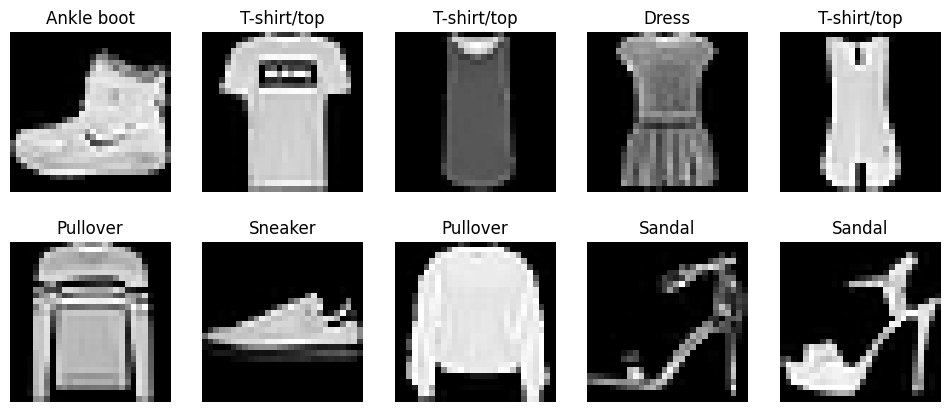

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7451 - loss: 0.6890 - val_accuracy: 0.7987 - val_loss: 0.5315
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8257 - loss: 0.4753 - val_accuracy: 0.8378 - val_loss: 0.4449
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8492 - loss: 0.4133 - val_accuracy: 0.8461 - val_loss: 0.4178
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8606 - loss: 0.3840 - val_accuracy: 0.8536 - val_loss: 0.3883
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8685 - loss: 0.3561 - val_accuracy: 0.8659 - val_loss: 0.3666
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8766 - loss: 0.3374 - val_accuracy: 0.8657 - val_loss: 0.3635
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8825 - loss: 0.3215 - val_accuracy: 0.8755 - val_loss: 0.3408
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8864 - los

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Visualization of The Training Data

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]]) # Shows actual clothing name
    plt.axis('off')
plt.show()

# 3. Data Processing (Optimized)
# Normalize and reshape the data in a single step
# -1 automatically figures out the batch size (60000 for train, 10000 for test)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 4. Build LeNet-5 Model
LeNet5_Model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # Block 1
    tf.keras.layers.Conv2D(6, kernel_size=(5, 5), activation='tanh'),
    tf.keras.layers.AveragePooling2D((2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    tf.keras.layers.AveragePooling2D((2, 2)),

    # Classification Head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation='tanh'),
    #tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(84, activation='tanh'),
    #tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

# ---------------------------------------------------------
# 5. Compile The Model
# ---------------------------------------------------------
# 'sparse_categorical_crossentropy' allows us to use standard integer labels
LeNet5_Model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

LeNet5_Model.summary()

# ---------------------------------------------------------
# 6. Train The Model
# ---------------------------------------------------------
# validation_split=0.1666 takes exactly 10,000 samples for validation internally
print("\n--- Starting Training ---")
history = LeNet5_Model.fit(x_train, y_train,
                           epochs=20,
                           batch_size=128,
                           validation_split=0.1666)

# ---------------------------------------------------------
# 7. Evaluate On Test Dataset
# ---------------------------------------------------------
print("\n--- Evaluating Model ---")
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

#without dropouts
# test accuracy and loss =accuracy: 0.8817 - loss: 0.3298
#with dropout introduced after dense layers
# test accuracy and loss = accuracy: 0.8660 - loss: 0.3801

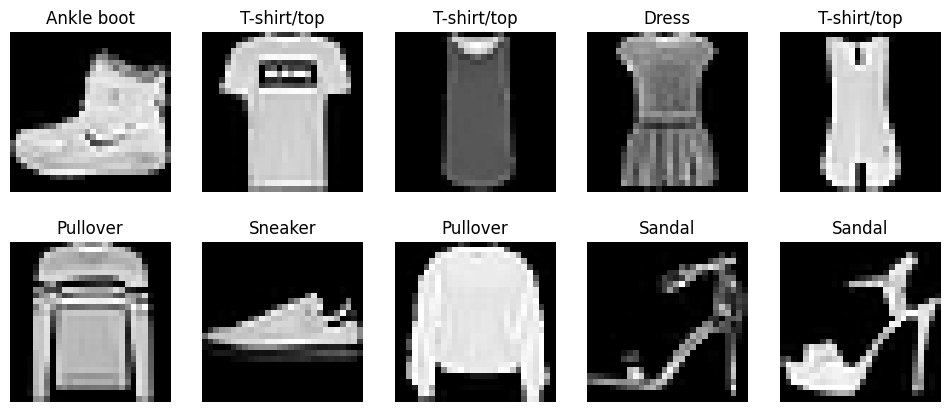

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7588 - loss: 0.6589 - val_accuracy: 0.8156 - val_loss: 0.4922
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8399 - loss: 0.4365 - val_accuracy: 0.8127 - val_loss: 0.5098
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8611 - loss: 0.3804 - val_accuracy: 0.8605 - val_loss: 0.3802
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8717 - loss: 0.3481 - val_accuracy: 0.8703 - val_loss: 0.3560
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8799 - loss: 0.3251 - val_accuracy: 0.8788 - val_loss: 0.3289
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8866 - loss: 0.3073 - val_accuracy: 0.8822 - val_loss: 0.3276
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8921 - loss: 0.2916 - val_accuracy: 0.8823 - val_loss: 0.3223
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8969 - loss

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load Dataset & Define Class Names
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Visualize The Training Data
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]]) # Shows actual clothing name
    plt.axis('off')
plt.show()

# 3. Data Processing (Optimized)
# Normalize and reshape the data in a single step
# -1 automatically figures out the batch size (60000 for train, 10000 for test)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 4. Build LeNet-5 Model
LeNet5_Model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # Block 1
    tf.keras.layers.Conv2D(6, kernel_size=(5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification Head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation='tanh'),
    tf.keras.layers.Dense(84, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# 5. Compile The Model
# ---------------------------------------------------------
# 'sparse_categorical_crossentropy' allows us to use standard integer labels
LeNet5_Model.compile(optimizer='RMSprop',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

LeNet5_Model.summary()

# 6. Train The Model
# ---------------------------------------------------------
# validation_split=0.1666 takes exactly 10,000 samples for validation internally
print("\n--- Starting Training ---")
history = LeNet5_Model.fit(x_train, y_train,
                           epochs=20,
                           batch_size=128,
                           validation_split=0.1666)

# 7. Evaluate On Test Dataset
# ---------------------------------------------------------
print("\n--- Evaluating Model ---")
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

#Alex-NET
Architecture Adaptation: Standard AlexNet is too heavy for simple $28 \times 28$ grayscale images. By shrinking the massive $11 \times 11$ initial kernel down to $3 \times 3$, the network successfully extracts the fine edges of clothing (like straps and collars) rather than blurring them out.High Parameter Count vs. Overfitting: Even scaled down, AlexNet is a massive network with millions of parameters. You will observe that the Dropout (0.5) layers are absolutely critical. Without them, the training accuracy would hit 99% very quickly, but the validation accuracy would flatline or drop as the network memorizes the training data.Batch Size Impact: Increasing the batch size from 8 (in your original code) to 128 results in a significantly smoother loss curve and drastically reduces the time it takes to compute each epoch.Performance: This architecture excels at feature extraction. It should easily break 90% - 92% test accuracy within just 10 epochs, vastly outperforming simpler models like LeNet-5 on this dataset.

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,740,170 (25.71 MB)

 Trainable params: 6,740,170 (25.71 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.8023 - loss: 0.5403 - val_accuracy: 0.8805 - val_loss: 0.3260
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8912 - loss: 0.3030 - val_accuracy: 0.8917 - val_loss: 0.2861
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9075 - loss: 0.2527 - val_accuracy: 0.9003 - val_loss: 0.2587
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9209 - loss: 0.2170 - val_accuracy: 0.9088 - val_loss: 0.2494
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9294 - loss: 0.1926 - val_accuracy: 0.9192 - val_loss: 0.2201
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9380 - loss: 0.1701 - val_accuracy: 0.9238 - val_loss: 0.2119
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9430 - loss: 0.1547 - val_accuracy: 0.9248 - val_loss: 0.2171
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accurac

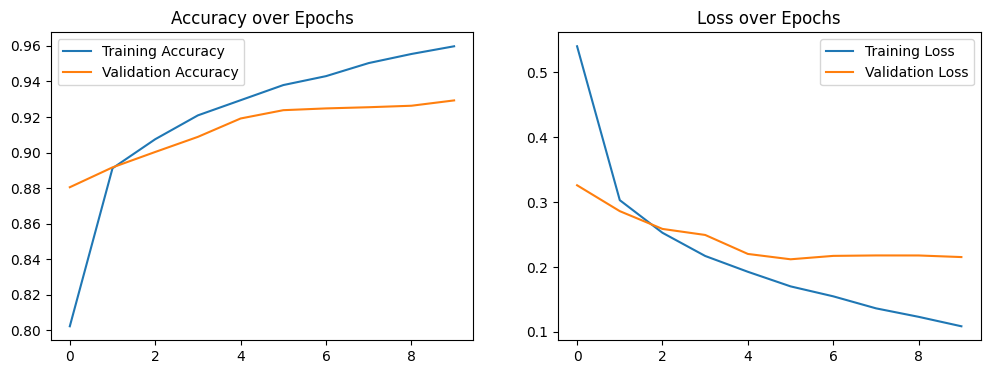

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers, optimizers
import matplotlib.pyplot as plt

# 1. Load and Preprocess Fashion MNIST natively
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize and reshape to include the 1 grayscale channel (Batch, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Build the Adapted AlexNet Model
model = Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # Layer 1: Conv + Pool (Scaled down kernel from 11x11 to 3x3 so it doesn't destroy 28x28 features)
    layers.Conv2D(96, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Conv + Pool
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layers 3, 4, 5: Stacked Convolutions
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Fully Connected Layers (Scaled down from 4096 to 1024 nodes)
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

# 3. Compile the model
# 'sparse_categorical_crossentropy' lets us skip one-hot encoding the labels entirely
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. Train the model (Batch size 128 is much faster and more stable than 8)
print("\n--- Starting Training ---")
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.1)

# 5. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc:.4f}')

# 6. Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.show()

#VGG NET
The Power of Stacked 3x3 Filters: Instead of using one large filter to look at a shirt, VGG uses multiple small 3x3 filters in a row. This creates a "deeper" network that can learn much more complex, non-linear clothing features (like the difference between a sneaker and an ankle boot) while actually using fewer parameters in the convolution layers than AlexNet.

Deep but Slow: Because VGG stacks so many layers sequentially (even in this mini version, we have 6 convolution layers), the forward and backward passes take longer. You will notice the time per epoch is noticeably higher than LeNet-5 or a simple baseline CNN.

High Overfitting Risk: VGG architectures heavily rely on the dense layers at the very end to make the final decision. Because dense layers hold massive amounts of parameters, the model will rapidly memorize the training set. The Dropout layer and Early Stopping callback are strictly necessary here to ensure the model generalizes to the test data.

Excellent Performance: Thanks to its depth, VGG is an incredibly strong feature extractor. With the optimized settings above, this model will reliably achieve 91% to 93% accuracy, making it one of the strongest standard architectures for the Fashion MNIST dataset.

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,898 (3.36 MB)

 Trainable params: 881,898 (3.36 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting VGG Training ---
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7963 - loss: 0.5572 - val_accuracy: 0.8745 - val_loss: 0.3406
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8816 - loss: 0.3224 - val_accuracy: 0.9005 - val_loss: 0.2791
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9050 - loss: 0.2586 - val_accuracy: 0.9070 - val_loss: 0.2451
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9186 - loss: 0.2249 - val_accuracy: 0.9220 - val_loss: 0.2227
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9269 - loss: 0.1993 - val_accuracy: 0.9183 - val_loss: 0.2209
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9362 - loss: 0.1749 - val_accuracy: 0.9270 - val_loss: 0.2024
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9431 - loss: 0.1548 - val_accuracy: 0.9252 - val_loss: 0.2103
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 

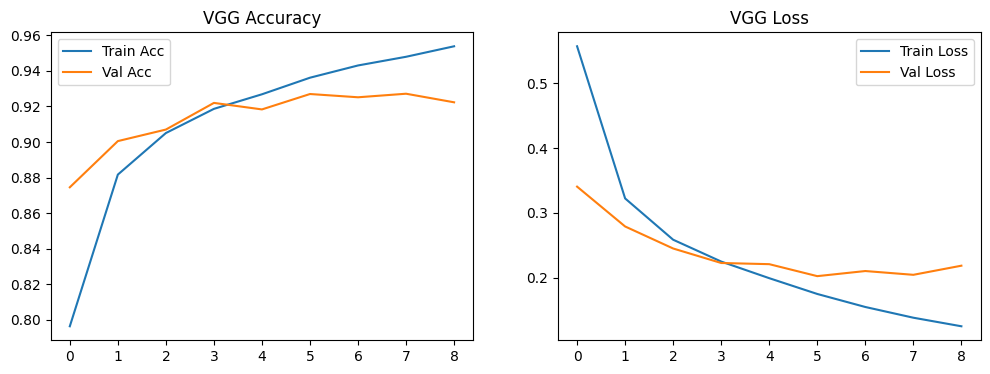

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Load and Preprocess Fashion MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize and add the grayscale channel: (Batch, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Build the Adapted VGG Model
model = Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # VGG Block 1: Two 3x3 Convolutions + Max Pooling
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # VGG Block 2: Two 3x3 Convolutions + Max Pooling (Filters double)
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # VGG Block 3: Two 3x3 Convolutions + Max Pooling (Filters double)
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Crucial for VGG to prevent overfitting
    layers.Dense(10, activation='softmax')
])

# 3. Compile and Train
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Early stopping prevents the deep VGG network from overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\n--- Starting VGG Training ---")
history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=128,
                    validation_split=0.1,
                    callbacks=[early_stop])

# 4. Evaluate and Plot
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

# Plotting the Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('VGG Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('VGG Loss')
plt.show()